In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset shape: (480, 3)
   timestamp service        cost
0 2024-01-01     EC2  122.483571
1 2024-01-01  Lambda   32.596733
2 2024-01-01     RDS   76.037396
3 2024-01-01      S3   43.955160
4 2024-01-02     EC2  120.267916


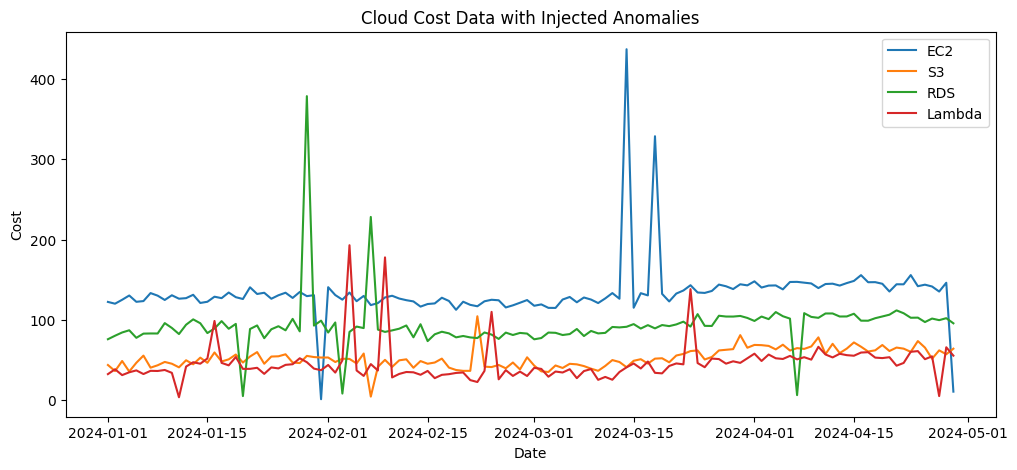

Dataset saved as cloud_cost_data.csv

========== VALIDATION: LEVEL 1 ==========

Expected rows: 480
Actual rows: 480

Columns: ['timestamp', 'service', 'cost']

Missing values:
 timestamp    0
service      0
cost         0
dtype: int64

Unique services: ['EC2' 'Lambda' 'RDS' 'S3']

Cost statistics:
 count    480.000000
mean      81.476114
std       45.462490
min        1.351147
25%       46.592909
50%       76.222477
75%      115.122592
max      437.063365
Name: cost, dtype: float64

Is data sorted correctly? True

--- Service-wise anomaly check ---
EC2: High=2, Low=2
Lambda: High=5, Low=0
RDS: High=2, Low=3
S3: High=3, Low=1

========== VALIDATION COMPLETE ==========


In [6]:
# =========================================================
# LEVEL 1: DATA INGESTION & SETUP (FINAL)
# =========================================================

# -------------------------------
# 1. IMPORTS
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# 2. CONFIG
# -------------------------------
NUM_DAYS = 120
SERVICES = ['EC2', 'S3', 'RDS', 'Lambda']

BASE_COST = {
    'EC2': 120,
    'S3': 40,
    'RDS': 80,
    'Lambda': 30
}

# -------------------------------
# 3. DATE RANGE
# -------------------------------
dates = pd.date_range(start="2024-01-01", periods=NUM_DAYS, freq='D')

# -------------------------------
# 4. GENERATE BASE DATA
# -------------------------------
data = []

for service in SERVICES:
    base = BASE_COST[service]

    trend = np.linspace(0, 20, NUM_DAYS)
    seasonality = 10 * np.sin(np.linspace(0, 3*np.pi, NUM_DAYS))
    noise = np.random.normal(0, 5, NUM_DAYS)

    cost_series = base + trend + seasonality + noise

    for i in range(NUM_DAYS):
        data.append([
            dates[i],
            service,
            max(cost_series[i], 1)
        ])

df = pd.DataFrame(data, columns=['timestamp', 'service', 'cost'])

# -------------------------------
# 5. STRONG ANOMALY INJECTION
# -------------------------------
def inject_anomalies(df):
    df = df.copy()
    np.random.seed(42)

    # Select indices
    spike_indices = np.random.choice(len(df), 10, replace=False)
    drop_indices = np.random.choice(len(df), 8, replace=False)

    # Inject SPIKES (strong increase)
    for idx in spike_indices:
        df.loc[idx, 'cost'] *= np.random.uniform(2.5, 4.5)

    # Inject DROPS (extreme decrease)
    for idx in drop_indices:
        df.loc[idx, 'cost'] *= np.random.uniform(0.01, 0.1)

    return df, spike_indices, drop_indices

df, spike_idx, drop_idx = inject_anomalies(df)

# -------------------------------
# 6. SORT DATA
# -------------------------------
df = df.sort_values(by=['timestamp', 'service']).reset_index(drop=True)

# -------------------------------
# 7. BASIC INFO
# -------------------------------
print("Dataset shape:", df.shape)
print(df.head())

# -------------------------------
# 8. VISUALIZATION
# -------------------------------
plt.figure(figsize=(12, 5))

for service in SERVICES:
    subset = df[df['service'] == service]
    plt.plot(subset['timestamp'], subset['cost'], label=service)

plt.title("Cloud Cost Data with Injected Anomalies")
plt.xlabel("Date")
plt.ylabel("Cost")
plt.legend()
plt.show()

# -------------------------------
# 9. SAVE DATA
# -------------------------------
df.to_csv("cloud_cost_data.csv", index=False)

print("Dataset saved as cloud_cost_data.csv")

# =========================================================
# 10. VALIDATION BLOCK (CRITICAL)
# =========================================================

print("\n========== VALIDATION: LEVEL 1 ==========\n")

# Row check
expected_rows = NUM_DAYS * len(SERVICES)
print("Expected rows:", expected_rows)
print("Actual rows:", len(df))

# Column check
print("\nColumns:", df.columns.tolist())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

# Services
print("\nUnique services:", df['service'].unique())

# Cost stats
print("\nCost statistics:\n", df['cost'].describe())

# Sorting check
is_sorted = df.sort_values(['timestamp', 'service']).equals(df)
print("\nIs data sorted correctly?", is_sorted)

# -------------------------------
# SERVICE-WISE ANOMALY CHECK
# -------------------------------
print("\n--- Service-wise anomaly check ---")

for service in df['service'].unique():
    subset = df[df['service'] == service]

    mean = subset['cost'].mean()
    std = subset['cost'].std()

    high = (subset['cost'] > mean + 2*std).sum()
    low = (subset['cost'] < mean - 2*std).sum()

    print(f"{service}: High={high}, Low={low}")

print("\n========== VALIDATION COMPLETE ==========")

In [7]:
# =========================================================
# LEVEL 2: PREPROCESSING (TIME INTELLIGENCE)
# =========================================================

import pandas as pd
import numpy as np

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("cloud_cost_data.csv")

# -------------------------------
# 2. DATETIME CONVERSION
# -------------------------------
df['timestamp'] = pd.to_datetime(df['timestamp'])

# -------------------------------
# 3. TIME FEATURES
# -------------------------------
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
df['day_name'] = df['timestamp'].dt.day_name()

df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df['week'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['month'] = df['timestamp'].dt.month

# -------------------------------
# 4. SERVICE ENCODING
# -------------------------------
df['service_encoded'] = df['service'].astype('category').cat.codes

# -------------------------------
# 5. SORT (VERY IMPORTANT)
# -------------------------------
df = df.sort_values(by=['service', 'timestamp']).reset_index(drop=True)

# -------------------------------
# 6. PREVIEW
# -------------------------------
print(df.head())

# -------------------------------
# 7. SAVE PROCESSED DATA
# -------------------------------
df.to_csv("cloud_cost_processed.csv", index=False)

print("Processed dataset saved as cloud_cost_processed.csv")

   timestamp service        cost  day_of_week   day_name  is_weekend  week  \
0 2024-01-01     EC2  122.483571            0     Monday           0     1   
1 2024-01-02     EC2  120.267916            1    Tuesday           0     1   
2 2024-01-03     EC2  125.151958            2  Wednesday           0     1   
3 2024-01-04     EC2  130.473053            3   Thursday           0     1   
4 2024-01-05     EC2  122.616769            4     Friday           0     1   

   month  service_encoded  
0      1                0  
1      1                0  
2      1                0  
3      1                0  
4      1                0  
Processed dataset saved as cloud_cost_processed.csv


In [8]:
# =========================================================
# LEVEL 2 VALIDATION
# =========================================================

print("\n========== VALIDATION: LEVEL 2 ==========\n")

# 1. Check datetime
print("Timestamp dtype:", df['timestamp'].dtype)

# 2. Check new columns
expected_cols = [
    'day_of_week', 'day_name', 'is_weekend',
    'week', 'month', 'service_encoded'
]

print("\nChecking new columns:")
for col in expected_cols:
    print(f"{col}:", "OK" if col in df.columns else "MISSING")

# 3. Check service encoding consistency
print("\nService Encoding Mapping:")
print(df[['service', 'service_encoded']].drop_duplicates().sort_values('service'))

# 4. Check weekend logic
weekend_check = df.groupby('day_of_week')['is_weekend'].mean()
print("\nWeekend logic check:\n", weekend_check)

# 5. Check sorting per service
is_sorted = True
for service in df['service'].unique():
    subset = df[df['service'] == service]
    if not subset['timestamp'].is_monotonic_increasing:
        is_sorted = False

print("\nIs each service sorted by time?", is_sorted)

# 6. Check duplicates
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)

print("\n========== VALIDATION COMPLETE ==========")


========== VALIDATION: LEVEL 2 ==========

Timestamp dtype: datetime64[ns]

Checking new columns:
day_of_week: OK
day_name: OK
is_weekend: OK
week: OK
month: OK
service_encoded: OK

Service Encoding Mapping:
    service  service_encoded
0       EC2                0
120  Lambda                1
240     RDS                2
360      S3                3

Weekend logic check:
 day_of_week
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    1.0
6    1.0
Name: is_weekend, dtype: float64

Is each service sorted by time? True

Duplicate rows: 0

========== VALIDATION COMPLETE ==========


In [9]:
# =========================================================
# LEVEL 3: CONTEXT-AWARE FEATURE ENGINEERING
# =========================================================

import pandas as pd
import numpy as np

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("cloud_cost_processed.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# -------------------------------
# 2. SORT (CRITICAL)
# -------------------------------
df = df.sort_values(by=['service', 'timestamp']).reset_index(drop=True)

# -------------------------------
# 3. ROLLING FEATURES (PER SERVICE)
# -------------------------------
df['rolling_mean_7'] = df.groupby('service')['cost'] \
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())

df['rolling_std_7'] = df.groupby('service')['cost'] \
    .transform(lambda x: x.rolling(window=7, min_periods=1).std())

# Fill NaN std (first few rows)
df['rolling_std_7'] = df['rolling_std_7'].fillna(0)

# -------------------------------
# 4. DEVIATION FEATURES
# -------------------------------
df['deviation'] = df['cost'] - df['rolling_mean_7']

df['pct_deviation'] = df['deviation'] / (df['rolling_mean_7'] + 1e-5)

# -------------------------------
# 5. TREND FEATURES
# -------------------------------
df['cost_prev'] = df.groupby('service')['cost'].shift(1)

df['cost_change'] = df['cost'] - df['cost_prev']

df['cost_change_rate'] = df['cost_change'] / (df['cost_prev'] + 1e-5)

# Fill initial NaNs
df[['cost_prev', 'cost_change', 'cost_change_rate']] = \
    df[['cost_prev', 'cost_change', 'cost_change_rate']].fillna(0)

# -------------------------------
# 6. CLEANUP
# -------------------------------
df.replace([np.inf, -np.inf], 0, inplace=True)

# -------------------------------
# 7. SAVE
# -------------------------------
df.to_csv("cloud_cost_features.csv", index=False)

print("Feature dataset saved as cloud_cost_features.csv")

# -------------------------------
# 8. PREVIEW
# -------------------------------
print(df.head(10))

Feature dataset saved as cloud_cost_features.csv
   timestamp service        cost  day_of_week   day_name  is_weekend  week  \
0 2024-01-01     EC2  122.483571            0     Monday           0     1   
1 2024-01-02     EC2  120.267916            1    Tuesday           0     1   
2 2024-01-03     EC2  125.151958            2  Wednesday           0     1   
3 2024-01-04     EC2  130.473053            3   Thursday           0     1   
4 2024-01-05     EC2  122.616769            4     Friday           0     1   
5 2024-01-06     EC2  123.526953            5   Saturday           1     1   
6 2024-01-07     EC2  133.479621            6     Sunday           1     1   
7 2024-01-08     EC2  130.277966            0     Monday           0     2   
8 2024-01-09     EC2  124.917652            1    Tuesday           0     2   
9 2024-01-10     EC2  130.764939            2  Wednesday           0     2   

   month  service_encoded  rolling_mean_7  rolling_std_7  deviation  \
0      1             

In [10]:
# =========================================================
# LEVEL 3 VALIDATION
# =========================================================

print("\n========== VALIDATION: LEVEL 3 ==========\n")

# 1. Check new columns
expected_cols = [
    'rolling_mean_7', 'rolling_std_7',
    'deviation', 'pct_deviation',
    'cost_prev', 'cost_change', 'cost_change_rate'
]

print("Checking feature columns:")
for col in expected_cols:
    print(f"{col}:", "OK" if col in df.columns else "MISSING")

# 2. Check NaNs
print("\nMissing values:\n", df[expected_cols].isnull().sum())

# 3. Check infinite values
inf_check = np.isinf(df[expected_cols]).sum()
print("\nInfinite values:\n", inf_check)

# 4. Sanity check (sample)
print("\nSample feature values:")
print(df[['service', 'cost', 'rolling_mean_7', 'deviation', 'pct_deviation']].head(10))

# 5. Check variability (VERY IMPORTANT)
print("\nFeature variability:")
print(df[['deviation', 'pct_deviation', 'cost_change_rate']].describe())

print("\n========== VALIDATION COMPLETE ==========")


========== VALIDATION: LEVEL 3 ==========

Checking feature columns:
rolling_mean_7: OK
rolling_std_7: OK
deviation: OK
pct_deviation: OK
cost_prev: OK
cost_change: OK
cost_change_rate: OK

Missing values:
 rolling_mean_7      0
rolling_std_7       0
deviation           0
pct_deviation       0
cost_prev           0
cost_change         0
cost_change_rate    0
dtype: int64

Infinite values:
 rolling_mean_7      0
rolling_std_7       0
deviation           0
pct_deviation       0
cost_prev           0
cost_change         0
cost_change_rate    0
dtype: int64

Sample feature values:
  service        cost  rolling_mean_7  deviation  pct_deviation
0     EC2  122.483571      122.483571   0.000000       0.000000
1     EC2  120.267916      121.375743  -1.107827      -0.009127
2     EC2  125.151958      122.634482   2.517476       0.020528
3     EC2  130.473053      124.594124   5.878928       0.047185
4     EC2  122.616769      124.198653  -1.581884      -0.012737
5     EC2  123.526953      124.

In [11]:
# =========================================================
# LEVEL 4: BASELINE MODELING
# =========================================================

import pandas as pd
import numpy as np

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("cloud_cost_features.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# -------------------------------
# 2. DEFINE SENSITIVITY
# -------------------------------
K = 2  # controls strictness

# -------------------------------
# 3. CREATE BOUNDS
# -------------------------------
df['upper_bound'] = df['rolling_mean_7'] + K * df['rolling_std_7']
df['lower_bound'] = df['rolling_mean_7'] - K * df['rolling_std_7']

# -------------------------------
# 4. BASELINE ANOMALY FLAG
# -------------------------------
df['baseline_anomaly'] = 0

df.loc[df['cost'] > df['upper_bound'], 'baseline_anomaly'] = 1
df.loc[df['cost'] < df['lower_bound'], 'baseline_anomaly'] = -1

# -------------------------------
# 5. VOLATILITY FEATURE
# -------------------------------
df['volatility'] = df['rolling_std_7'] / (df['rolling_mean_7'] + 1e-5)

# -------------------------------
# 6. CLEANUP
# -------------------------------
df.replace([np.inf, -np.inf], 0, inplace=True)

# -------------------------------
# 7. SAVE
# -------------------------------
df.to_csv("cloud_cost_baseline.csv", index=False)

print("Baseline dataset saved as cloud_cost_baseline.csv")

# -------------------------------
# 8. PREVIEW
# -------------------------------
print(df[['service', 'cost', 'upper_bound', 'lower_bound', 'baseline_anomaly']].head(10))

Baseline dataset saved as cloud_cost_baseline.csv
  service        cost  upper_bound  lower_bound  baseline_anomaly
0     EC2  122.483571   122.483571   122.483571                 0
1     EC2  120.267916   124.509152   118.242335                 0
2     EC2  125.151958   127.525513   117.743450                 0
3     EC2  130.473053   133.391358   115.796891                 0
4     EC2  122.616769   132.019871   116.377436                 0
5     EC2  123.526953   131.103678   117.069728                 0
6     EC2  133.479621   134.991340   115.865757                 0
7     EC2  130.277966   136.317359   116.766708                 0
8     EC2  124.917652   135.513747   118.898816                 0
9     EC2  130.764939   136.472334   119.543938                 0


In [12]:
# =========================================================
# LEVEL 4 VALIDATION
# =========================================================

print("\n========== VALIDATION: LEVEL 4 ==========\n")

# 1. Column check
expected_cols = ['upper_bound', 'lower_bound', 'baseline_anomaly', 'volatility']

print("Checking columns:")
for col in expected_cols:
    print(f"{col}:", "OK" if col in df.columns else "MISSING")

# 2. Logical check: bounds
invalid_bounds = (df['upper_bound'] < df['lower_bound']).sum()
print("\nInvalid bounds (should be 0):", invalid_bounds)

# 3. Check anomaly distribution
print("\nBaseline anomaly distribution:")
print(df['baseline_anomaly'].value_counts())

# 4. Sanity check sample
print("\nSample check:")
sample = df[['cost', 'lower_bound', 'upper_bound', 'baseline_anomaly']].head(10)
print(sample)

# 5. Volatility stats
print("\nVolatility stats:")
print(df['volatility'].describe())

print("\n========== VALIDATION COMPLETE ==========")


========== VALIDATION: LEVEL 4 ==========

Checking columns:
upper_bound: OK
lower_bound: OK
baseline_anomaly: OK
volatility: OK

Invalid bounds (should be 0): 0

Baseline anomaly distribution:
baseline_anomaly
 0    463
 1     10
-1      7
Name: count, dtype: int64

Sample check:
         cost  lower_bound  upper_bound  baseline_anomaly
0  122.483571   122.483571   122.483571                 0
1  120.267916   118.242335   124.509152                 0
2  125.151958   117.743450   127.525513                 0
3  130.473053   115.796891   133.391358                 0
4  122.616769   116.377436   132.019871                 0
5  123.526953   117.069728   131.103678                 0
6  133.479621   115.865757   134.991340                 0
7  130.277966   116.766708   136.317359                 0
8  124.917652   118.898816   135.513747                 0
9  130.764939   119.543938   136.472334                 0

Volatility stats:
count    480.000000
mean       0.181811
std        0.230551


In [13]:
# =========================================================
# LEVEL 5: ISOLATION FOREST
# =========================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("cloud_cost_baseline.csv")

# -------------------------------
# 2. FEATURE SELECTION
# -------------------------------
features = [
    'cost',
    'rolling_mean_7',
    'rolling_std_7',
    'deviation',
    'pct_deviation',
    'cost_change_rate',
    'volatility'
]

X = df[features]

# -------------------------------
# 3. SCALING (CRITICAL)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. MODEL TRAINING
# -------------------------------
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # expected anomaly %
    random_state=42
)

model.fit(X_scaled)

# -------------------------------
# 5. PREDICTIONS
# -------------------------------
df['anomaly_label'] = model.predict(X_scaled)  # -1 = anomaly, 1 = normal

# Convert to 1 (anomaly), 0 (normal)
df['anomaly_flag'] = df['anomaly_label'].apply(lambda x: 1 if x == -1 else 0)

# -------------------------------
# 6. ANOMALY SCORE
# -------------------------------
df['anomaly_score'] = model.decision_function(X_scaled)

# Lower score = more anomalous
df['anomaly_score'] = -df['anomaly_score']

# -------------------------------
# 7. SAVE
# -------------------------------
df.to_csv("cloud_cost_model_output.csv", index=False)

print("Model output saved as cloud_cost_model_output.csv")

# -------------------------------
# 8. PREVIEW
# -------------------------------
print(df[['cost', 'anomaly_flag', 'anomaly_score']].head(10))

Model output saved as cloud_cost_model_output.csv
         cost  anomaly_flag  anomaly_score
0  122.483571             0      -0.155332
1  120.267916             0      -0.181643
2  125.151958             0      -0.188619
3  130.473053             0      -0.203015
4  122.616769             0      -0.208830
5  123.526953             0      -0.213274
6  133.479621             0      -0.184755
7  130.277966             0      -0.204538
8  124.917652             0      -0.208070
9  130.764939             0      -0.208080


In [14]:
# =========================================================
# LEVEL 5 VALIDATION
# =========================================================

print("\n========== VALIDATION: LEVEL 5 ==========\n")

# 1. Check columns
expected_cols = ['anomaly_flag', 'anomaly_score']
print("Checking columns:")
for col in expected_cols:
    print(f"{col}:", "OK" if col in df.columns else "MISSING")

# 2. Anomaly distribution
print("\nAnomaly distribution:")
print(df['anomaly_flag'].value_counts())

# 3. Score stats
print("\nAnomaly score stats:")
print(df['anomaly_score'].describe())

# 4. Compare with baseline
print("\nBaseline vs ML comparison:")
comparison = pd.crosstab(df['baseline_anomaly'], df['anomaly_flag'])
print(comparison)

# 5. Top anomalies
print("\nTop anomalies:")
print(df.sort_values(by='anomaly_score', ascending=False)[
    ['service', 'cost', 'anomaly_score']
].head(10))

print("\n========== VALIDATION COMPLETE ==========")




========== VALIDATION: LEVEL 5 ==========

Checking columns:
anomaly_flag: OK
anomaly_score: OK

Anomaly distribution:
anomaly_flag
0    456
1     24
Name: count, dtype: int64

Anomaly score stats:
count    480.000000
mean      -0.171861
std        0.075725
min       -0.237569
25%       -0.216614
50%       -0.203254
75%       -0.156943
max        0.185439
Name: anomaly_score, dtype: float64

Baseline vs ML comparison:
anomaly_flag        0   1
baseline_anomaly         
-1                  3   4
 0                450  13
 1                  3   7

Top anomalies:
    service        cost  anomaly_score
73      EC2  437.063365       0.185439
268     RDS  378.649553       0.180226
77      EC2  328.750378       0.141224
154  Lambda  193.066490       0.133925
277     RDS  228.280373       0.112339
273     RDS    8.389724       0.108735
159  Lambda  177.920538       0.105336
31      EC2  140.809028       0.090693
174  Lambda  110.076438       0.083719
202  Lambda  138.392478       0.082672

=

In [15]:
# =========================================================
# LEVEL 6: SHAP EXPLAINABILITY
# =========================================================

import pandas as pd
import numpy as np
import shap

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("cloud_cost_model_output.csv")

# -------------------------------
# 2. FEATURES (same as Level 5)
# -------------------------------
features = [
    'cost',
    'rolling_mean_7',
    'rolling_std_7',
    'deviation',
    'pct_deviation',
    'cost_change_rate',
    'volatility'
]

X = df[features]

# -------------------------------
# 3. SCALE AGAIN (IMPORTANT)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. RELOAD MODEL (IMPORTANT)
# -------------------------------
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
model.fit(X_scaled)

# -------------------------------
# 5. SHAP EXPLAINER
# -------------------------------
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_scaled)

# -------------------------------
# 6. STORE SHAP VALUES
# -------------------------------
shap_df = pd.DataFrame(shap_values, columns=features)

# Merge into main dataframe
df_shap = pd.concat([df.reset_index(drop=True), shap_df], axis=1)

# -------------------------------
# 7. TOP FEATURE CONTRIBUTOR
# -------------------------------
def get_top_feature(row):
    abs_vals = row[features].abs()
    return abs_vals.idxmax()

df_shap['top_feature'] = shap_df.abs().idxmax(axis=1)

# -------------------------------
# 8. SAVE
# -------------------------------
df_shap.to_csv("cloud_cost_shap_output.csv", index=False)

print("SHAP output saved as cloud_cost_shap_output.csv")

# -------------------------------
# 9. PREVIEW
# -------------------------------
print(df_shap[['service', 'cost', 'anomaly_flag', 'top_feature']].head(10))

SHAP output saved as cloud_cost_shap_output.csv
  service        cost      cost  anomaly_flag    top_feature
0     EC2  122.483571 -0.073601             0     volatility
1     EC2  120.267916  0.007052             0  rolling_std_7
2     EC2  125.151958 -0.058893             0  pct_deviation
3     EC2  130.473053 -0.143474             0  rolling_std_7
4     EC2  122.616769  0.027210             0  rolling_std_7
5     EC2  123.526953  0.015131             0  pct_deviation
6     EC2  133.479621 -0.283921             0     volatility
7     EC2  130.277966 -0.097115             0  rolling_std_7
8     EC2  124.917652  0.030696             0  rolling_std_7
9     EC2  130.764939 -0.114590             0  rolling_std_7


In [16]:
# =========================================================
# LEVEL 6 VALIDATION
# =========================================================

print("\n========== VALIDATION: LEVEL 6 ==========\n")

# 1. Check SHAP columns
missing_cols = [col for col in features if col not in df_shap.columns]
print("Missing SHAP columns:", missing_cols)

# 2. Check top_feature column
print("\nTop feature column exists:",
      "top_feature" in df_shap.columns)

# 3. SHAP value stats
print("\nSHAP stats:")
print(df_shap[features].describe())

# 4. Check anomalies explanations
print("\nSample anomaly explanations:")
print(df_shap[df_shap['anomaly_flag'] == 1][
    ['service', 'cost', 'top_feature']
].head(10))

# 5. Feature importance distribution
print("\nTop feature distribution:")
print(df_shap['top_feature'].value_counts())

print("\n========== VALIDATION COMPLETE ==========")


========== VALIDATION: LEVEL 6 ==========

Missing SHAP columns: []

Top feature column exists: True

SHAP stats:
             cost        cost  rolling_mean_7  rolling_mean_7  rolling_std_7  \
count  480.000000  480.000000      480.000000      480.000000     480.000000   
mean    81.476114    0.005602       81.258816       -0.015732      14.140934   
std     45.462490    0.317980       37.746978        0.314673      23.288818   
min      1.351147   -1.861600       29.780826       -1.561685       0.000000   
25%     46.592909   -0.058519       48.629421       -0.153212       3.870391   
50%     76.222477    0.105476       76.390626        0.093150       5.112448   
75%    115.122592    0.199591      115.305460        0.219847       7.309985   
max    437.063365    0.367717      200.703934        0.380863     128.899606   

       rolling_std_7   deviation   deviation  pct_deviation  pct_deviation  \
count     480.000000  480.000000  480.000000     480.000000     480.000000   
mean    

In [17]:
# =========================================================
# LEVEL 7: AIS (ANOMALY INTELLIGENCE SCORE)
# =========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("cloud_cost_shap_output.csv")

# -------------------------------
# 2. DEFINE SHAP FEATURE COLUMNS
# -------------------------------
features = [
    'cost',
    'rolling_mean_7',
    'rolling_std_7',
    'deviation',
    'pct_deviation',
    'cost_change_rate',
    'volatility'
]

# -------------------------------
# 3. BUILD AIS COMPONENTS
# -------------------------------

# A. ML anomaly strength
df['ml_signal_raw'] = df['anomaly_score']

# B. Deviation intensity
df['deviation_signal_raw'] = df['pct_deviation'].abs()

# C. Explainability intensity
df['shap_signal_raw'] = df[features].abs().max(axis=1)

# D. Behavioral instability
df['volatility_signal_raw'] = df['volatility'].abs()

# -------------------------------
# 4. NORMALIZE COMPONENTS
# -------------------------------
scaler = MinMaxScaler()

signal_cols = [
    'ml_signal_raw',
    'deviation_signal_raw',
    'shap_signal_raw',
    'volatility_signal_raw'
]

normalized_cols = [
    'ml_signal_norm',
    'deviation_signal_norm',
    'shap_signal_norm',
    'volatility_signal_norm'
]

df[normalized_cols] = scaler.fit_transform(df[signal_cols])

# -------------------------------
# 5. AIS WEIGHTS
# -------------------------------
W_ML = 0.35
W_DEV = 0.30
W_SHAP = 0.20
W_VOL = 0.15

# -------------------------------
# 6. COMPUTE AIS
# -------------------------------
df['ais_score'] = 100 * (
    W_ML * df['ml_signal_norm'] +
    W_DEV * df['deviation_signal_norm'] +
    W_SHAP * df['shap_signal_norm'] +
    W_VOL * df['volatility_signal_norm']
)

# -------------------------------
# 7. AIS SEVERITY BAND
# -------------------------------
def assign_ais_band(score):
    if score >= 75:
        return 'Critical'
    elif score >= 50:
        return 'High'
    elif score >= 25:
        return 'Medium'
    else:
        return 'Low'

df['ais_band'] = df['ais_score'].apply(assign_ais_band)

# -------------------------------
# 8. SAVE
# -------------------------------
df.to_csv("cloud_cost_ais_output.csv", index=False)

print("AIS output saved as cloud_cost_ais_output.csv")

# -------------------------------
# 9. PREVIEW
# -------------------------------
print(df[['service', 'cost', 'anomaly_flag', 'anomaly_score', 'ais_score', 'ais_band']].head(10))

AIS output saved as cloud_cost_ais_output.csv
  service        cost  anomaly_flag  anomaly_score  ais_score ais_band
0     EC2  122.483571             0      -0.155332  11.356657      Low
1     EC2  120.267916             0      -0.181643   9.450896      Low
2     EC2  125.151958             0      -0.188619   9.331439      Low
3     EC2  130.473053             0      -0.203015   9.022267      Low
4     EC2  122.616769             0      -0.208830   7.668064      Low
5     EC2  123.526953             0      -0.213274   7.125886      Low
6     EC2  133.479621             0      -0.184755  10.973375      Low
7     EC2  130.277966             0      -0.204538   8.675029      Low
8     EC2  124.917652             0      -0.208070   7.973427      Low
9     EC2  130.764939             0      -0.208080   8.205740      Low


In [18]:
# =========================================================
# LEVEL 7 VALIDATION
# =========================================================

print("\n========== VALIDATION: LEVEL 7 ==========\n")

# 1. Column check
expected_cols = [
    'ml_signal_raw', 'deviation_signal_raw', 'shap_signal_raw', 'volatility_signal_raw',
    'ml_signal_norm', 'deviation_signal_norm', 'shap_signal_norm', 'volatility_signal_norm',
    'ais_score', 'ais_band'
]

print("Checking AIS columns:")
for col in expected_cols:
    print(f"{col}:", "OK" if col in df.columns else "MISSING")

# 2. Check normalized range
print("\nNormalized signal ranges:")
for col in normalized_cols:
    print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")

# 3. AIS score stats
print("\nAIS score stats:")
print(df['ais_score'].describe())

# 4. AIS band distribution
print("\nAIS band distribution:")
print(df['ais_band'].value_counts())

# 5. Compare anomaly flag with AIS
print("\nAIS vs anomaly flag:")
print(pd.crosstab(df['anomaly_flag'], df['ais_band']))

# 6. Top AIS cases
print("\nTop AIS records:")
print(df.sort_values(by='ais_score', ascending=False)[
    ['service', 'cost', 'anomaly_flag', 'anomaly_score', 'ais_score', 'ais_band', 'top_feature']
].head(10))

print("\n========== VALIDATION COMPLETE ==========")


========== VALIDATION: LEVEL 7 ==========

Checking AIS columns:
ml_signal_raw: OK
deviation_signal_raw: OK
shap_signal_raw: OK
volatility_signal_raw: OK
ml_signal_norm: OK
deviation_signal_norm: OK
shap_signal_norm: OK
volatility_signal_norm: OK
ais_score: OK
ais_band: OK

Normalized signal ranges:
ml_signal_norm: min=0.0000, max=1.0000
deviation_signal_norm: min=0.0000, max=1.0000
shap_signal_norm: min=0.0000, max=1.0000
volatility_signal_norm: min=0.0000, max=1.0000

AIS score stats:
count    480.000000
mean      12.791025
std       13.095877
min        2.524581
25%        5.605298
50%        7.805558
75%       12.800103
max       92.367927
Name: ais_score, dtype: float64

AIS band distribution:
ais_band
Low         421
Medium       48
High          8
Critical      3
Name: count, dtype: int64

AIS vs anomaly flag:
ais_band      Critical  High  Low  Medium
anomaly_flag                             
0                    0     0  421      35
1                    3     8    0      13

T

In [23]:
# =========================================================
# LEVEL 8: DECISION INTELLIGENCE ENGINE (FIXED)
# =========================================================

import pandas as pd
import numpy as np

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("cloud_cost_ais_output.csv")

# -------------------------------
# 2. ANOMALY TYPE (FIXED)
# -------------------------------
def classify_anomaly(row):
    if row['anomaly_flag'] == 0:
        return "Normal"

    if row['pct_deviation'] > 0.5 and row['cost_change_rate'] > 0.5:
        return "Sudden Spike"
    elif row['pct_deviation'] < -0.5 and row['cost_change_rate'] < -0.5:
        return "Sudden Drop"
    elif row['volatility'] > 0.5:
        return "Instability"
    elif row['pct_deviation'] > 0.2:
        return "Gradual Increase"
    else:
        return "Unclassified Anomaly"

df['anomaly_type'] = df.apply(classify_anomaly, axis=1)

# -------------------------------
# 3. ROOT CAUSE (UNCHANGED)
# -------------------------------
def infer_root_cause(row):
    if row['anomaly_flag'] == 0:
        return "No anomaly"

    if row['top_feature'] == 'cost_change_rate':
        return "Sudden usage surge (possible scaling event)"
    elif row['top_feature'] == 'pct_deviation':
        return "Significant deviation from normal usage"
    elif row['top_feature'] == 'rolling_std_7':
        return "Unstable usage pattern over time"
    elif row['top_feature'] == 'volatility':
        return "Highly inconsistent workload behavior"
    elif row['top_feature'] == 'cost':
        return "Absolute cost spike"
    elif row['top_feature'] == 'deviation':
        return "Deviation from expected baseline"
    else:
        return "General anomaly pattern"

df['root_cause'] = df.apply(infer_root_cause, axis=1)

# -------------------------------
# 4. CONFIDENCE (FIXED)
# -------------------------------
def compute_confidence(row):
    if row['anomaly_flag'] == 0:
        return 0

    # AIS already 0–100
    base = row['ais_score']

    # SHAP dominance boost
    dominance = abs(row[row['top_feature']])
    dominance = min(dominance, 1)  # cap to avoid explosion

    confidence = base * (0.7 + 0.3 * dominance)

    return min(confidence, 100)

df['confidence'] = df.apply(compute_confidence, axis=1)

# -------------------------------
# 5. RECOMMENDED ACTION (IMPROVED)
# -------------------------------
def recommend_action(row):
    if row['anomaly_flag'] == 0:
        return "No action needed"

    if row['anomaly_type'] == "Sudden Spike":
        return "Check autoscaling, deployments, or misconfigurations immediately"
    elif row['anomaly_type'] == "Sudden Drop":
        return "Check for service outages or disabled resources"
    elif row['anomaly_type'] == "Instability":
        return "Investigate workload fluctuations and stabilize usage patterns"
    elif row['anomaly_type'] == "Gradual Increase":
        return "Review long-term scaling trends and optimize resource allocation"
    else:
        return "Investigate anomaly manually for deeper insights"

df['recommended_action'] = df.apply(recommend_action, axis=1)

# -------------------------------
# 6. SAVE FINAL OUTPUT
# -------------------------------
df.to_csv("cloud_cost_final_output.csv", index=False)

print("Final decision output saved as cloud_cost_final_output.csv")

# -------------------------------
# 7. PREVIEW (ONLY ANOMALIES)
# -------------------------------
print(df[df['anomaly_flag'] == 1][
    ['service', 'cost', 'ais_score', 'ais_band',
     'anomaly_type', 'root_cause', 'confidence', 'recommended_action']
].head(10))

Final decision output saved as cloud_cost_final_output.csv
    service        cost  ais_score  ais_band      anomaly_type  \
30      EC2    1.351147  51.229836      High       Sudden Drop   
31      EC2  140.809028  42.530537    Medium  Gradual Increase   
73      EC2  437.063365  88.059974  Critical      Sudden Spike   
74      EC2  115.238751  43.144295    Medium       Instability   
77      EC2  328.750378  64.907837      High      Sudden Spike   
78      EC2  132.514012  47.588291    Medium       Instability   
79      EC2  123.075498  48.018806    Medium       Instability   
119     EC2   10.790694  49.374227    Medium       Sudden Drop   
135  Lambda   98.821462  51.828466      High      Sudden Spike   
154  Lambda  193.066490  82.069485  Critical      Sudden Spike   

                                      root_cause  confidence  \
30              Deviation from expected baseline   51.229836   
31   Sudden usage surge (possible scaling event)   42.530537   
73                    

In [25]:
# =========================================================
# LEVEL 8 VALIDATION (FIXED)
# =========================================================

print("\n========== VALIDATION: LEVEL 8 (FIXED) ==========\n")

# 1. Distribution
print("Anomaly type distribution:")
print(df['anomaly_type'].value_counts())

# 2. Check Normal vs anomaly separation
print("\nNormal vs anomaly:")
print(pd.crosstab(df['anomaly_flag'], df['anomaly_type']))

# 3. Confidence stats
print("\nConfidence stats:")
print("\nConfidence stats (ANOMALIES ONLY):")
print(df[df['anomaly_flag'] == 1]['confidence'].describe())

# 4. Only anomalies
print("\nAnomaly decisions:")
print(df[df['anomaly_flag'] == 1][
    ['service', 'cost', 'anomaly_type', 'root_cause', 'confidence']
].head(10))

print("\n========== VALIDATION COMPLETE ==========")


========== VALIDATION: LEVEL 8 (FIXED) ==========

Anomaly type distribution:
anomaly_type
Normal                  456
Sudden Spike             10
Sudden Drop               6
Instability               4
Gradual Increase          2
Unclassified Anomaly      2
Name: count, dtype: int64

Normal vs anomaly:
anomaly_type  Gradual Increase  Instability  Normal  Sudden Drop  \
anomaly_flag                                                       
0                            0            0     456            0   
1                            2            4       0            6   

anomaly_type  Sudden Spike  Unclassified Anomaly  
anomaly_flag                                      
0                        0                     0  
1                       10                     2  

Confidence stats:

Confidence stats (ANOMALIES ONLY):
count    24.000000
mean     54.863092
std      16.371902
min      31.161715
25%      44.859158
50%      49.086279
75%      64.847728
max      92.367927
Name: conf

In [26]:
# =========================================================
# DOWNLOAD PROJECT FILES FROM COLAB
# =========================================================

from google.colab import files

files_to_download = [
    "cloud_cost_data.csv",
    "cloud_cost_processed.csv",
    "cloud_cost_features.csv",
    "cloud_cost_baseline.csv",
    "cloud_cost_model_output.csv",
    "cloud_cost_shap_output.csv",
    "cloud_cost_ais_output.csv",
    "cloud_cost_final_output.csv"
]

for file in files_to_download:
    try:
        files.download(file)
    except:
        print(f"{file} not found")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>